<a href="https://colab.research.google.com/github/misterziem/us-recession-probit-model/blob/main/recession_probit_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data and Yield Spread Calculation

In [11]:
import datetime
import pandas as pd
import pandas_datareader.data as web

# FRED ingestion: 10Y/2Y yields and NBER recession dates
start_date = datetime.datetime(1976, 6, 1)
tickers = ["DGS10", "DGS2", "USREC"]
raw_data = web.DataReader(tickers, "fred", start=start_date)

# Month-end alignment (business days)
df_monthly = raw_data.resample("ME").last().ffill().dropna()
df_monthly["Spread"] = df_monthly["DGS10"] - df_monthly["DGS2"]

df_monthly.tail()

,DGS10,DGS2,USREC,Spread
DATE,,,,
2026-05-31,4.45,3.98,0.0,0.47
2026-06-30,4.44,4.14,0.0,0.30
2026-07-31,4.75,4.28,0.0,0.47
2026-08-31,4.75,4.34,0.0,0.41
2026-09-30,4.77,4.34,0.0,0.43


## 2. Econometric Estimation: Estrella & Mishkin Probit Model

In [12]:
import statsmodels.api as sm

# 12-month forward horizon to replicate Estrella & Mishkin (1998)
df_monthly["USREC_lead12"] = df_monthly["USREC"].shift(-12)
train_df = df_monthly.dropna(subset=["USREC_lead12"])

y = train_df["USREC_lead12"]
X = sm.add_constant(train_df[["Spread"]])

probit_model = sm.Probit(y, X).fit()
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.267725
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:           USREC_lead12   No. Observations:                  592
Model:                         Probit   Df Residuals:                      590
Method:                           MLE   Df Model:                            1
Date:                Sat, 05 Sep 2026   Pseudo R-squ.:                  0.1649
Time:                        23:20:46   Log-Likelihood:                -158.49
converged:                       True   LL-Null:                       -189.80
Covariance Type:            nonrobust   LLR p-value:                 2.518e-15
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9376      0.084    -11.210      0.000      -1.102      -0.774
Spread        -0.7197      0.

## 3. Historical Probability Estimation and Visualization

/tmp/ipykernel_1680/3159413844.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Prob_Recession"] = probit_model.predict(X) * 100


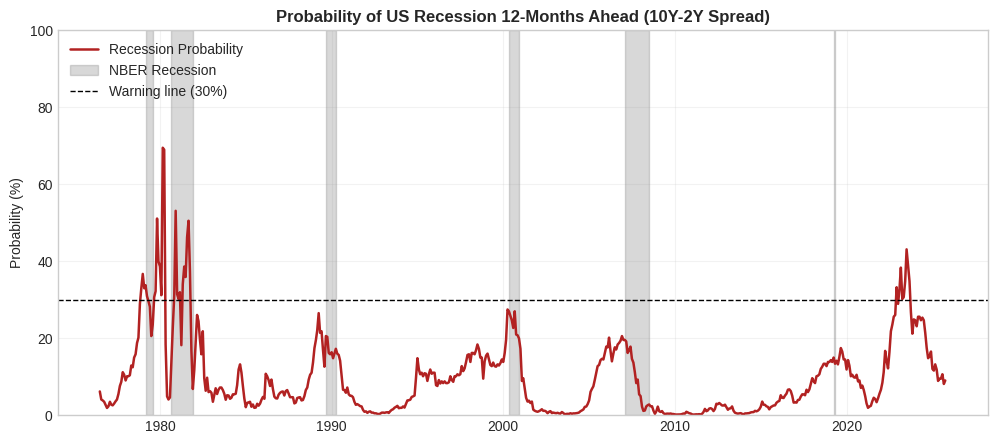

In [14]:
import matplotlib.pyplot as plt

train_df["Prob_Recession"] = probit_model.predict(X) * 100

plt.figure(figsize=(12, 5))
plt.plot(
    train_df.index,
    train_df["Prob_Recession"],
    color="firebrick",
    lw=1.8,
    label="Recession Probability",
)
plt.fill_between(
    train_df.index,
    0,
    100,
    where=train_df["USREC_lead12"] == 1,
    color="grey",
    alpha=0.3,
    label="NBER Recession",
)

# Warning threshold from Estrella & Mishkin (1998)
plt.axhline(
    30, color="black", linestyle="--", linewidth=1, label="Warning line (30%)"
)

plt.title(
    "Probability of US Recession 12-Months Ahead (10Y-2Y Spread)",
    fontweight="bold",
)
plt.ylabel("Probability (%)")
plt.ylim(0, 100)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.25)

plt.show()